In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

# Cascades

In [3]:
zbest_path = '/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/cascades/3.2/ELG/alltiles_ELGzinfo.fits'
tmp = fitsio.read(zbest_path, columns=['TARGETS', 'subset'])
idx = np.where((tmp['subset']=='deep') & ((tmp['TARGETS']=='ELG') | (tmp['TARGETS']=='QSO+ELG')))[0]
zbest = Table(fitsio.read(zbest_path, rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

77734
77197


In [4]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

FIBERSTATUS 65562 12172 0.15658527799933106
No data 65550 12 0.00018303285439736432


In [5]:
# Target-visits
np.sum(zbest['COADD_NUMEXP'])

511950

In [6]:
# Print summary of the tiles
t = Table()
t['TILEID'], t['count'] = np.unique(zbest['TILEID'], return_counts=True)
t['efftime'] = 0
t['n_exp'] = 0
for index, tileid in enumerate(t['TILEID']):
    mask = zbest['TILEID']==tileid
    t['n_exp'][index] = np.max(zbest['COADD_NUMEXP'][mask])
    t['efftime'][index] = np.max(zbest['EFFTIME_DARK'][mask])
t.sort('efftime')
t

TILEID,count,efftime,n_exp
int32,int64,int64,int64
80695,2680,795,1
80687,2908,1301,1
80703,3023,1409,4
80689,2993,3146,3
80701,2826,3290,6
80705,2983,3403,7
80679,2358,3467,8
80673,2301,3544,9
80677,2157,3550,9


In [7]:
min_depth = 4000
mask = zbest['EFFTIME_DARK']>min_depth
print('EFFTIME_DARK > {}: {}'.format(min_depth, np.sum(mask)))

min_depth = 3000
mask = zbest['EFFTIME_DARK']>min_depth
print('EFFTIME_DARK > {}: {}'.format(min_depth, np.sum(mask)))

min_depth = 2000
mask = zbest['EFFTIME_DARK']>min_depth
print('EFFTIME_DARK > {}: {}'.format(min_depth, np.sum(mask)))

min_depth = 1000
mask = zbest['EFFTIME_DARK']>min_depth
print('EFFTIME_DARK > {}: {}'.format(min_depth, np.sum(mask)))

min_depth = 0
mask = zbest['EFFTIME_DARK']>min_depth
print('EFFTIME_DARK > {}: {}'.format(min_depth, np.sum(mask)))

EFFTIME_DARK > 4000: 32913
EFFTIME_DARK > 3000: 54121
EFFTIME_DARK > 2000: 55647
EFFTIME_DARK > 1000: 62210
EFFTIME_DARK > 0: 65550


-------
# Post-cascades

In [14]:
cat = Table.read('/global/cfs/cdirs/desi/survey/observations/SV1/sv1-exposures.fits')
print(len(cat))

mask = ((cat['TARGETS']=='ELG') | (cat['TARGETS']=='QSO+ELG'))
cat = cat[mask]
print(len(cat))

1516
340


In [15]:
mask = cat['EFFTIME_DARK']/cat['EXPTIME']>0.3
print(np.sum(mask), np.sum(mask)/len(mask))
cat = cat[mask]

224 0.6588235294117647


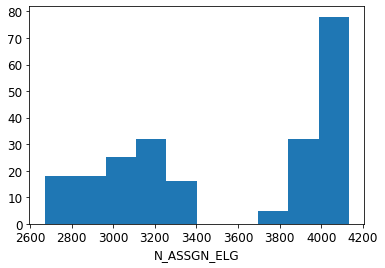

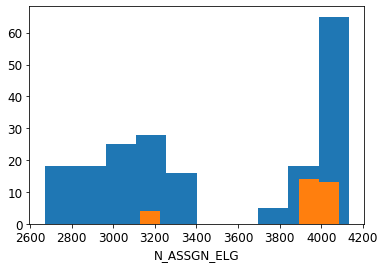

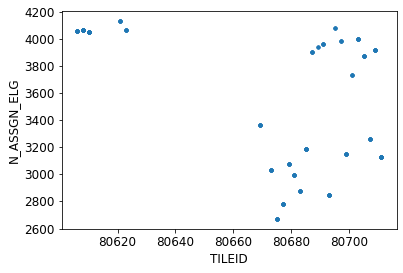

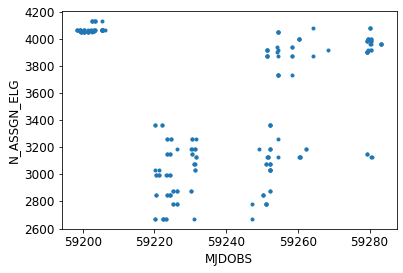

In [16]:
plt.hist(cat['N_ASSGN_ELG'])
plt.xlabel('N_ASSGN_ELG')
plt.show()

mask = cat['NIGHT']<=20210224
plt.hist(cat['N_ASSGN_ELG'][mask])
mask = cat['NIGHT']>20210224
plt.hist(cat['N_ASSGN_ELG'][mask])
plt.xlabel('N_ASSGN_ELG')
plt.show()

plt.plot(cat['TILEID'], cat['N_ASSGN_ELG'], '.')
plt.xlabel('TILEID')
plt.ylabel('N_ASSGN_ELG')
plt.show()

plt.plot(cat['MJDOBS'], cat['N_ASSGN_ELG'], '.')
plt.xlabel('MJDOBS')
plt.ylabel('N_ASSGN_ELG')
plt.show()

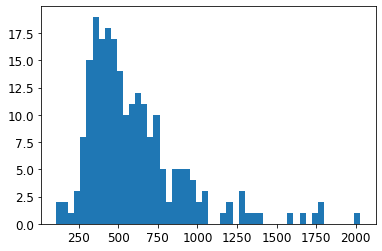

In [17]:
plt.hist(cat['EFFTIME_DARK'], 50);

Incremental progress since cascades: 21%


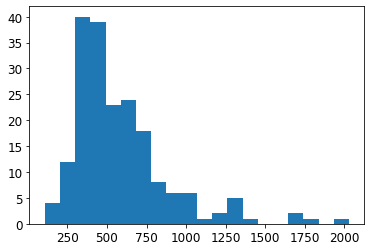

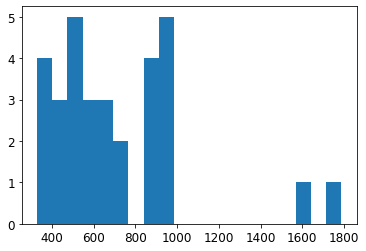

In [18]:
efftime_tot = np.sum(cat['EFFTIME_DARK']*cat['N_ASSGN_ELG'])
mask = cat['NIGHT']<=20210224
efftime_tot_cascades = np.sum(cat['EFFTIME_DARK'][mask]*cat['N_ASSGN_ELG'][mask])
print('Incremental progress since cascades: {:.0f}%'.format((efftime_tot/efftime_tot_cascades-1)*100))

mask = cat['NIGHT']<=20210224
plt.hist(cat['EFFTIME_DARK'][mask], 20)
plt.show()

mask = cat['NIGHT']>20210224
plt.hist(cat['EFFTIME_DARK'][mask], 20)
plt.show()